<a href="https://colab.research.google.com/github/Leonardo-Leal-Salazar/Probabilidad1/blob/main/Unidad4/Problema_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unidad 4
## Programa 1
### Falicitador: Jose Gabriel Rodriguez Rivas
### Alumno: Erik Leonardo Leal Salazar 🌇 🦊 🍂

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [8]:
# ── Parámetros del problema ──────────────────────────────────────────────────
media      = 70   # Media (kg)
desv_std   = 4    # Desviación estándar (kg)
num_datos  = 500  # Total de estudiantes

# ── 1. Generar datos aleatorios con distribución normal ──────────────────────
datos = np.random.normal(media, desv_std, num_datos)
print("Primeros 50 pesos generados:\n", datos[:50])

# ── 2. Rango de x y PDF ──────────────────────────────────────────────────────
x   = np.linspace(media - 3*desv_std, media + 3*desv_std, num_datos)
pdf = norm.pdf(x, media, desv_std)   # Usando scipy directamente

Primeros 50 pesos generados:
 [63.43381641 65.67384855 59.55937351 70.85125118 73.81949761 68.15758646
 63.71168535 72.10976415 68.40571296 65.87925588 70.97208227 67.98973137
 76.27969191 67.23654598 69.42385297 70.9390767  69.11735407 64.09253539
 69.23188574 62.30895076 71.36405022 68.60591172 66.98140556 65.38784863
 72.85244204 71.48090826 66.30158726 73.57426942 73.94021853 76.69144461
 66.43946355 74.015171   69.21672492 71.59171102 71.44457273 74.99110004
 77.86808005 70.870164   68.60258728 68.09859022 78.74563787 76.13245271
 74.1190022  68.60614853 68.26301992 69.23138982 73.55775371 66.72793992
 68.58341914 64.1905029 ]



Probabilidad de que un estudiante pese entre 68 y 72 kg: 0.3829 (38.29%)
Número de estudiantes que pesan entre 68 y 72 kg: 191 de 500


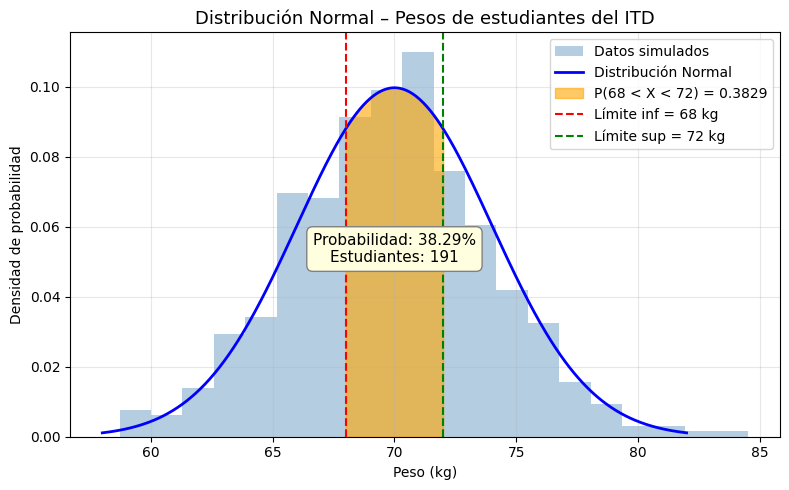

In [11]:
# ── 3. Calcular la probabilidad P(68 < X < 72) ─────────────────────────────
lim_inf = 68
lim_sup = 72

prob = norm.cdf(lim_sup, media, desv_std) - norm.cdf(lim_inf, media, desv_std)
print(f"\nProbabilidad de que un estudiante pese entre {lim_inf} y {lim_sup} kg: {prob:.4f} ({prob*100:.2f}%)")

# ── 4. Número de estudiantes en ese rango ────────────────────────────────────
estudiantes = round(prob * num_datos)
print(f"Número de estudiantes que pesan entre {lim_inf} y {lim_sup} kg: {estudiantes} de {num_datos}")

# ── 5. Graficar ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))

# Histograma de los datos simulados
plt.hist(datos, bins=20, density=True, alpha=0.4, color='steelblue', label='Datos simulados')

# Curva de la distribución normal
plt.plot(x, pdf, 'b-', linewidth=2, label='Distribución Normal')

# Sombrear el área entre 68 y 72 kg
x_fill = np.linspace(lim_inf, lim_sup, 300)
plt.fill_between(x_fill, norm.pdf(x_fill, media, desv_std),
                 alpha=0.6, color='orange',
                 label=f'P({lim_inf} < X < {lim_sup}) = {prob:.4f}')

# Líneas verticales en los límites
plt.axvline(lim_inf, color='red', linestyle='--', linewidth=1.5, label=f'Límite inf = {lim_inf} kg')
plt.axvline(lim_sup, color='green', linestyle='--', linewidth=1.5, label=f'Límite sup = {lim_sup} kg')

# Anotación con los resultados
plt.annotate(f'Probabilidad: {prob*100:.2f}%\nEstudiantes: {estudiantes}',
             xy=((lim_inf + lim_sup) / 2, norm.pdf(media, media, desv_std) / 2),
             fontsize=11, ha='center',
             bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray'))

plt.title('Distribución Normal – Pesos de estudiantes del ITD', fontsize=13)
plt.xlabel('Peso (kg)')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
